# 6.5.3 数据划分与独立验证

## 学习目标与先修知识

能依据预测任务划分训练集（training set）、验证集（validation set）和测试集（test set）；防止数据泄漏（data leakage）；处理缺失观测（observation）而不压缩时间；固定预处理和候选模型（model）后解释独立评估、残差（residual）与外推（extrapolation）范围。

先修：[ARX 回归与两种预测](01-ARX回归与两种预测.ipynb)、[激励与可辨识范围](02-激励与可辨识范围.ipynb)，以及均值、标准差（standard deviation）和最小二乘。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

一段生理记录有几处缺测。把空值删除、整段减均值，再随机抽几行评估，代码可以顺利完成，然而模型已经借用了未来分布（distribution），并把相隔两秒的值当成只隔一秒。我们需要先说明未来使用场景，再决定允许哪些信息进入拟合与预测。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE,PINK,GRAY='#008bfb','#ff0051','#555555'

## 初步实验

In [2]:
times=[0,1,2,3,4,5];values=[1.,None,3.,4.,None,6.]
valid=[i for i,v in enumerate(values) if v is not None]
display(Markdown(show_table(['有效原始索引','原时间 / T','观测 / U'],[(i,times[i],values[i]) for i in valid])))
print('删除空值后相邻元素的真实时间间隔：',np.diff([times[i] for i in valid]).tolist())

| 有效原始索引 | 原时间 / T | 观测 / U |
| --- | --- | --- |
| 0 | 0 | 1 |
| 2 | 2 | 3 |
| 3 | 3 | 4 |
| 5 | 5 | 6 |

删除空值后相邻元素的真实时间间隔： [2, 1, 2]


## 模型假设

本节先评估“同一个体将来的一步预测（one-step-ahead prediction）”：每拍已知上一拍实际观测和当前输入（input），不能使用当前目标或未来观测。采样（sampling）间隔固定为 1 T，输出（output）单位 U，输入单位 V。按目标时刻划分：$t<50$ 训练，$50\le t<75$ 验证，$t\ge75$ 最终测试。边界和两个输入延迟（delay）候选（0 拍或 1 拍额外延迟）在查看结果前固定。

另一个任务是推广到新个体，需要把同一个体的全部记录放在同一集合；按时间分割同一个体不能单独证明新个体推广。如果问题同时要求新个体与未来时段，两个隔离条件都需满足。下面用一个短名单展示如何按个体分组。

实验记录在内存中构造：真实更新含平滑输入饱和，代码中输入先以 1 V 为参照取无量纲（dimensionless）数，再送入 tanh；饱和项前的 0.25 以 U 为单位。训练/验证输入在 ±0.5 V，测试输入扩大到 ±1.8 V。这是确定性的结构失配对照。构造时的真实系数与状态（state）仅用于生成理想课程记录，不传给拟合或模型选择函数。

## 数学解释与推导

### 划分先于所有需要拟合的变换

对训练行的某一回归特征 $x$，令 $\mu_{\mathrm{tr}}=\sum x_i/N_{\mathrm{tr}}$，$s_{\mathrm{tr}}=\sqrt{\sum(x_i-\mu_{\mathrm{tr}})^2/N_{\mathrm{tr}}}$，标准化（standardization）为 $z=(x-\mu_{\mathrm{tr}})/s_{\mathrm{tr}}$。若训练特征恒定，约定除数为 1，保留其无变异的事实。验证、测试原样使用这些训练统计量（statistic）；重算它们也属于利用未见数据。

本节拟合带截距的线性预测 $\hat y=c+\beta^\mathsf{T}z$，目标仍保持 U；截距允许训练坐标平移，不预先假设它为零。若回到原特征单位，系数为 $\beta_j/s_j$，截距为 $c-\sum_j\beta_j\mu_j/s_j$。

### 缺测不是时间消失

原记录若在 $n=2$ 缺失，$y_1$ 不能被直接当成 $y_3$ 的一拍前值。先保留时间与索引；一阶回归行要求目标 $y_i$、上一拍 $y_{i-1}$ 及候选需要的输入均存在。本节丢弃不完整回归行，不对值作插补（imputation）；这保留索引语义，却不保证缺测机制无偏。若缺测取决于未观测状态，仍需单独研究。

评估区间第一拍可以使用区间之前、当时已到达的真实观测作为延迟项，这是一步预测的信息条件；自由运行（free-run simulation）则必须另设初态并递推自己的预测。不能在同一指标中悄悄切换两种模式。

### 训练、选择与最终评分

只用训练行拟合两种预定结构及各自标准化；比较**相同验证目标行**的均方根误差（root mean squared error，RMSE）$\sqrt{\sum_i(y_i-\hat y_i)^2/N}$，按较小值选择，精确并列时选较小延迟。锁定所选模型后，只计算一次最终测试结果；不能因测试表现不好再选另一个模型并仍称它“未见评估”。

同时检查误差随时间的变化、输入是否超出训练范围、以及残差在相邻原时刻是否相关。结合 RMSE、相关系数（correlation coefficient）和输入范围，可以定位误差在哪些条件下增大。

## 核心实现

划分函数只返回原索引；拟合函数只接收训练矩阵（matrix）。缺失保持在原数组（array）中，每个候选使用同一批有效目标时刻。

In [3]:
def time_partition(times,values,train_end,validation_end):
    train=[];validation=[];test=[]
    for i,(t,x) in enumerate(zip(times,values)):
        if x is None:continue
        if t<train_end:train.append(i)
        elif t<validation_end:validation.append(i)
        else:test.append(i)
    return train,validation,test

def group_partition(individuals,training_groups,validation_groups):
    return ([i for i,g in enumerate(individuals) if g in training_groups],
            [i for i,g in enumerate(individuals) if g in validation_groups],
            [i for i,g in enumerate(individuals) if g not in training_groups and g not in validation_groups])

def fit_scaled_model(features,targets):
    mean=features.mean(axis=0);scale=features.std(axis=0)
    scale=np.where(scale==0,1.,scale)
    design=np.column_stack([np.ones(len(features)),(features-mean)/scale])
    coefficients,_,rank,_=np.linalg.lstsq(design,targets,rcond=None)
    if rank<design.shape[1]:raise ValueError('训练回归矩阵秩不足')
    return mean,scale,coefficients

def predict_scaled_model(model,features):
    mean,scale,coefficients=model
    return coefficients[0]+((features-mean)/scale)@coefficients[1:]

def candidate_rows(observed,inputs,indices,delay):
    # indices 已按全部候选共同需要的历史条件筛选。
    return np.array([[observed[i-1],inputs[i-1-delay]] for i in indices],dtype=float)

def rmse(targets,prediction):
    return float(np.sqrt(np.mean((np.asarray(targets)-prediction)**2)))

## 对照实验

先产生并划分课程记录，再拟合。此时只展示训练、验证计数和分数，测试目标尚未参与任何选择。

In [4]:
times=np.arange(101);inputs=np.where((np.arange(100)//5)%2,.5,-.5)
inputs[75:]=np.where((np.arange(75,100)//5)%2,1.8,-1.8)
record=[0.]
for u in inputs:record.append(.82*record[-1]+.25*np.tanh(u))
for i in [13,14,37,62,83]:record[i]=None
raw_groups=time_partition(times,record,50,75)
delays=[0,1]
groups=[]
for group in raw_groups:
    groups.append([i for i in group if i>=2 and record[i-1] is not None])
train_indices,validation_indices,test_indices=groups
train_target=np.array([record[i] for i in train_indices])
validation_target=np.array([record[i] for i in validation_indices])
models={};validation_scores={}
for delay in delays:
    train_features=candidate_rows(record,inputs,train_indices,delay)
    models[delay]=fit_scaled_model(train_features,train_target)
    validation_features=candidate_rows(record,inputs,validation_indices,delay)
    validation_prediction=predict_scaled_model(models[delay],validation_features)
    validation_scores[delay]=rmse(validation_target,validation_prediction)
chosen=min(delays,key=lambda delay:(validation_scores[delay],delay))
frozen_model=models[chosen]
display(Markdown(show_table(['额外输入延迟 / 拍','训练有效行','验证有效行','验证 RMSE / U'],[(d,len(train_indices),len(validation_indices),validation_scores[d]) for d in delays])))
print('按固定规则锁定额外延迟：',chosen)

| 额外输入延迟 / 拍 | 训练有效行 | 验证有效行 | 验证 RMSE / U |
| --- | --- | --- | --- |
| 0 | 43 | 23 | 7.08389e-17 |
| 1 | 43 | 23 | 0.0740619 |

按固定规则锁定额外延迟： 0


现在只对锁定模型计算一次测试预测，之后绘图和报告复用这一结果。测试中仍允许使用上一拍实际观测，因此评价的是一步预测。输入超出训练范围的时刻保留，并在图中标出。

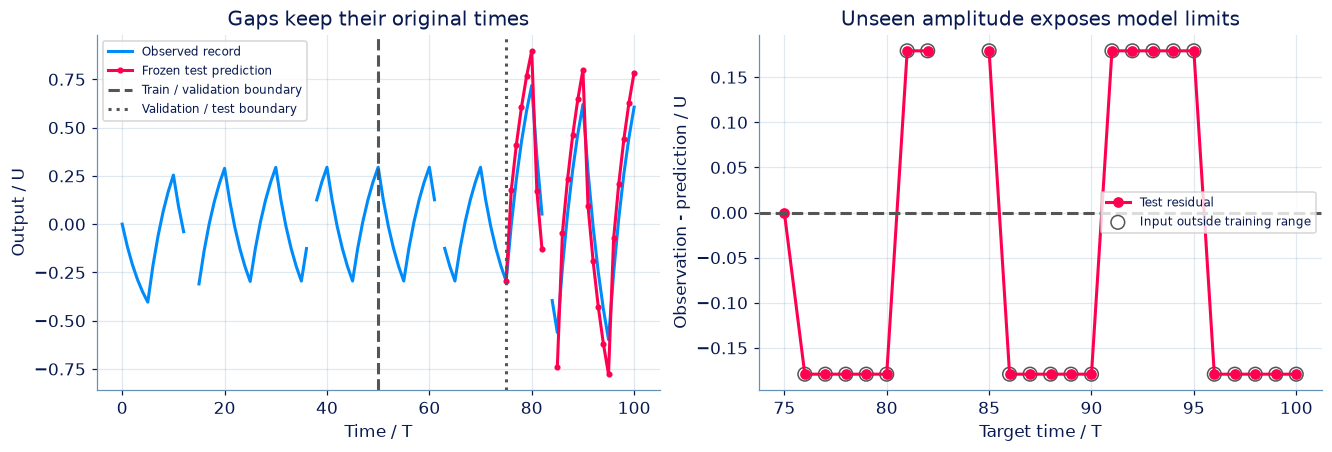

| 锁定后的评价 | 数值 |
| --- | --- |
| 测试有效行 | 24 |
| 测试 RMSE / U | 0.175431 |
| 范围外输入行数 | 23 |
| 相邻原时刻残差相关 | 0.55224 |

In [5]:
test_features=candidate_rows(record,inputs,test_indices,chosen)
test_target=np.array([record[i] for i in test_indices])
test_prediction=predict_scaled_model(frozen_model,test_features)
test_score=rmse(test_target,test_prediction)
test_residual=test_target-test_prediction
training_inputs=candidate_rows(record,inputs,train_indices,chosen)[:,1]
outside=(test_features[:,1]<training_inputs.min())|(test_features[:,1]>training_inputs.max())
adjacent=np.diff(test_indices)==1
lag_correlation=float(np.corrcoef(test_residual[:-1][adjacent],test_residual[1:][adjacent])[0,1])
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(times,[np.nan if v is None else v for v in record],color=BLUE,label='Observed record')
prediction_for_plot=np.full(len(times),np.nan);prediction_for_plot[test_indices]=test_prediction
axes[0].plot(times,prediction_for_plot,'o-',ms=3,color=PINK,label='Frozen test prediction')
axes[0].axvline(50,color=GRAY,ls='--',label='Train / validation boundary')
axes[0].axvline(75,color=GRAY,ls=':',label='Validation / test boundary')
axes[0].set(xlabel='Time / T',ylabel='Output / U',title='Gaps keep their original times');axes[0].legend(fontsize=8)
residual_for_plot=np.full(len(times),np.nan);residual_for_plot[test_indices]=test_residual
axes[1].plot(times,residual_for_plot,'o-',color=PINK,label='Test residual')
axes[1].scatter(np.array(test_indices)[outside],test_residual[outside],s=80,facecolors='none',edgecolors=GRAY,label='Input outside training range')
axes[1].axhline(0,color=GRAY,ls='--');axes[1].set(xlabel='Target time / T',ylabel='Observation - prediction / U',title='Unseen amplitude exposes model limits');axes[1].legend(fontsize=8)
plt.show()
display(Markdown(show_table(['锁定后的评价','数值'],[['测试有效行',len(test_indices)],['测试 RMSE / U',test_score],['范围外输入行数',int(outside.sum())],['相邻原时刻残差相关',lag_correlation]])))

## 结果解释

正确延迟的线性模型在训练与验证使用的 ±0.5 V 上能解释记录，但更大输入下真实饱和明显，线性外推过强。验证范围内表现好并不保证范围外机制正确。这段测试误差揭示了饱和结构的作用。若据此修改模型，下一次评估应使用新的预留数据。

缺失处留在原时钟中，不凭连续连线制造观测。标准化使用的是各候选的训练回归行统计量，不是全部原始点；相邻残差相关只使用原索引差为 1 的有效对。这里的相关数值描述这段残差的结构。

### 独立核对

使用小型手算例核对时间边界和个体隔离；把未见数据改成极端值，确认训练得到的变换不变；再把标准化回归还原到原坐标，并核对缺测附近没有跨时钟拼接。

In [6]:
assert time_partition([0,1,2,3,4,5],[1.,None,3.,4.,None,6.],2,4)==([0],[2,3],[5])
assert group_partition(['甲','乙','甲','丙','乙'],['甲'],['乙'])==([0,2],[1,4],[3])
assert time_partition([],[],2,4)==([],[],[])
assert group_partition([],[],[])==([],[],[])
changed_record=record.copy()
for i in range(50,len(changed_record)):
    if changed_record[i] is not None:changed_record[i]=1e6
changed_train=candidate_rows(changed_record,inputs,train_indices,chosen)
original_train=candidate_rows(record,inputs,train_indices,chosen)
np.testing.assert_allclose(changed_train,original_train)
mean,scale,beta=frozen_model
raw_slopes=beta[1:]/scale;raw_intercept=beta[0]-mean@raw_slopes
np.testing.assert_allclose(raw_intercept+test_features@raw_slopes,test_prediction,atol=1e-14)
assert all(record[i] is not None and record[i-1] is not None for group in groups for i in group)
assert not any(i in train_indices for i in [13,14,15,37,38])
assert chosen==0 and test_score>validation_scores[chosen]+.05
print('边界、个体隔离、训练预处理、原时钟与独立测试检查通过。')

边界、个体隔离、训练预处理、原时钟与独立测试检查通过。


## 练习与参考资料

习题由统一题库同步。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：保留原时钟的数据划分

观察时刻和缺测标记已给定。按固定边界返回训练、验证和最终评估三个集合的有效原始索引。

**函数与代码模板**

```python
def solve(
    times: list[float],
    values: list[float | None],
    train_end: float,
    validation_end: float,
) -> tuple[list[int], list[int], list[int]]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 严格递增的观察时刻。 | T |
| `values` | <code>list[float &#124; None]</code> | 同长度读数；None明确表示缺测。 | U |
| `train_end` | `float` | 训练区间右边界，不包含该时刻。 | T |
| `validation_end` | `float` | 验证区间右边界，不包含该时刻。 | T |

**返回值**

按以下顺序返回元组：(train_indices, validation_indices, test_indices)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `train_indices` | `list[int]` | 有效且t<train_end的原始索引。 | 索引 |
| `validation_indices` | `list[int]` | 有效且train_end≤t<validation_end的原始索引。 | 索引 |
| `test_indices` | `list[int]` | 有效且t≥validation_end的原始索引。 | 索引 |

**计算规则**

先按原时间边界分组，缺测值不加入任何索引；保留原始索引，不把缺测删除后的相邻项当成相邻时间步。

**约束与边界**

- 所有非缺测数值有限；不修改输入（input）列表。
- 0—100 个严格递增时刻，与values等长；绝对值≤1000；train_end<validation_end；非缺测读数绝对值≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| times | 严格递增的观察时刻。 | [0.0, 1.0, 2.0, 3.0, 4.0, 5.0] | T |
| values | 同长度读数；None明确表示缺测。 | [1.0, None, 3.0, 4.0, None, 6.0] | U |
| train_end | 训练区间右边界，不包含该时刻。 | 2 | T |
| validation_end | 验证区间右边界，不包含该时刻。 | 4 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
times = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
values = [1.0, None, 3.0, 4.0, None, 6.0]
train_end = 2.0
validation_end = 4.0

result = solve(times, values, train_end, validation_end)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| train_indices | 有效且t<train_end的原始索引。 | [0] | 索引 |
| validation_indices | 有效且train_end≤t<validation_end的原始索引。 | [2, 3] | 索引 |
| test_indices | 有效且t≥validation_end的原始索引。 | [5] | 索引 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0], [2, 3], [5])
```

**样例解释**

结果为([0],[2,3],[5])；时刻2归验证，时刻4虽然归最终时段却缺测，不进入任何集合。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：保留原时钟的数据划分](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-time-partition)

### 第 2 题 · Python 计算题：让同一个体留在同一数据集合

目标是评估对新个体的推广。给出每条记录的个体标签和预先固定的训练/验证个体名单，未在两名单内者进入最终评估。

**函数与代码模板**

```python
def solve(
    individuals: list[str],
    training_groups: list[str],
    validation_groups: list[str],
) -> tuple[list[int], list[int], list[int]]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `individuals` | `list[str]` | 按原记录顺序排列的个体标签。 | 1 |
| `training_groups` | `list[str]` | 预先指定的训练个体名单。 | 1 |
| `validation_groups` | `list[str]` | 预先指定的验证个体名单。 | 1 |

**返回值**

按以下顺序返回元组：(train_indices, validation_indices, test_indices)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `train_indices` | `list[int]` | 属于 training_groups 的原始记录索引。 | 索引 |
| `validation_indices` | `list[int]` | 属于 validation_groups 的原始记录索引。 | 索引 |
| `test_indices` | `list[int]` | 不属于两个名单的原始记录索引。 | 索引 |

**计算规则**

逐个原记录索引按个体所属名单划分；两名单无重叠，标签可重复出现。最终集合为未列入前两者的个体；不用每条记录单独随机分组。

**约束与边界**

- 所有非缺测数值有限；不修改输入（input）列表。
- 0—100条记录；标签长度1—12；两名单各不重复且互不重叠，可为空；允许名单中的个体暂未出现在记录里。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| individuals | 按原记录顺序排列的个体标签。 | ['甲', '乙', '甲', '丙', '乙'] | 1 |
| training_groups | 预先指定的训练个体名单。 | ['甲'] | 1 |
| validation_groups | 预先指定的验证个体名单。 | ['乙'] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
individuals = ['甲', '乙', '甲', '丙', '乙']
training_groups = ['甲']
validation_groups = ['乙']

result = solve(individuals, training_groups, validation_groups)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| train_indices | 属于 training_groups 的原始记录索引。 | [0, 2] | 索引 |
| validation_indices | 属于 validation_groups 的原始记录索引。 | [1, 4] | 索引 |
| test_indices | 不属于两个名单的原始记录索引。 | [3] | 索引 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0, 2], [1, 4], [3])
```

**样例解释**

结果([0,2],[1,4],[3])；甲的两条记录同属训练，不能一条训练一条评估新个体。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：让同一个体留在同一数据集合](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-group-partition)

### 第 3 题 · 单项选择题：标准化参数从哪里估计

按时间划定训练、验证和最终评估后，需要减均值除标准差（standard deviation）。哪项正确？

- **A.** 每个最终评估点都用它未来邻点更新变换，仍声称离线固定模型（model）。
- **B.** 先按最终评估误差挑变换，再报告同一最终误差为未见表现。
- **C.** 用全记录估计均值方差（variance），因为没有用到标签就不算泄漏。
- **D.** 只用训练段拟合变换，再原样用于验证和最终评估。

[作答：标准化参数从哪里估计](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-train-only-transform)

### 第 4 题 · 单项选择题：缺测点能直接拼接吗

等间隔记录y[0],y[1],None,y[3]，建立一阶ARX回归时哪项恰当？

- **A.** 借助验证段未来值填补训练缺测而无需记录。
- **B.** 删除None后把y[1]直接当y[3]的一拍前值。
- **C.** 保留原索引；含缺测目标或所需滞后项（lagged term）的回归行不直接用于拟合。
- **D.** 把None当0不会改变模型（model）。

[作答：缺测点能直接拼接吗](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-missing-lags)

### 第 5 题 · 多项选择题：验证与最终评估分别做什么

比较两个候选动态结构后准备报告性能。哪些正确？

- **A.** 训练拟合参数（parameter），验证用于预定候选选择，最终评估留待方案固定后。
- **B.** 同一个体记录跨训练/测试时可以无条件声称泛化到新个体。
- **C.** 范围外输入（input）表现差，应报告适用范围而不是删去这些点。
- **D.** 可报告残差（residual）时间相关，但单个统计量（statistic）不能证明机制唯一。

[作答：验证与最终评估分别做什么](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-held-out-purpose)

**进一步阅读**

[scikit-learn：数据泄漏与预处理](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)、[按组与时间的评估设计](https://scikit-learn.org/stable/modules/cross_validation.html)：数据隔离与评估设计的进一步阅读。